# Default versus globally fitted BinnedSED shapes

This tutorial compares two simultaneous true-energy SED fits:

1. `BinnedSED.from_response(response)`, whose default within-bin shape is a power law with index $-2$;
2. a global forward-folded spectral fit followed by `BinnedSED.from_response(response, spectral_shape=global_shape)`.

Both SED fits leave every bin normalization free and fit the same independent background scale. The second method freezes a copy of the globally fitted spectral shape inside the SED bins; it does **not** freeze the SED-bin normalizations.

The controlled cases are power laws with indices $-1$, $-2$, and $-3$, and cutoff power laws with index $-2$ and cutoff energies 200, 1000, and 5000 keV. Source expectations are generated in memory with `SourceInjector`. No injected histograms, tables, or figures are written to disk. The figures are displayed only as notebook outputs.

## 1. Imports and configuration

The DC4 background was produced with a 60-degree field-of-view selection around the source, so the same cut is applied to the orientation in memory.

In [1]:
from copy import deepcopy
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astromodels import Cutoff_powerlaw, Model, Parameter, PointSource, Powerlaw
from threeML import DataList, JointLikelihood, PluginPrototype, update_logging_level

from cosipy import BinnedData
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.response import BinnedInstrumentResponse, PointSourceResponse
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.integrals import get_integral_values
from cosipy.source_injector import SourceInjector
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml import BinnedSED, profile_likelihood_upper_limit

update_logging_level("ERROR")
%matplotlib inline

DC4_DATA_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)
ORIENTATION_PATH = DC4_DATA_DIR / (
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
)
RESPONSE_PATH = DC4_DATA_DIR / (
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284."
    "filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
BACKGROUND_PATH = DC4_DATA_DIR / (
    "Background/Total_DC4_BG_3months_binned_data_filtered_"
    "with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5"
)
CONFIG_PATH = Path("background.yaml")

SOURCE_COORD = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")
FOV_CUT = 60 * u.deg
POWERLAW_INDICES = (-1.0, -2.0, -3.0)
CUTOFF_ENERGIES_KEV = (200.0, 1000.0, 5000.0)
CUTOFF_INDEX = -2.0
PIVOT_KEV = 1000.0
INTEGRATED_PHOTON_FLUX = 5.0e-3
GLOBAL_START_K = 1.0e-7
SED_START_FLUXES = (1.0e-9, 1.0e-7, 1.0e-5)
TS_THRESHOLD = 4.0
TINY = np.finfo(float).tiny
FLUX_UNIT = 1.0 / (u.keV * u.cm**2 * u.s)

17:56:43 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=902413;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=786996;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=749009;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=350689;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

17:56:44 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=162482;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=523036;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

17:56:44 INFO      Starting 3ML!                                                                     ]8;id=574596;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=205075;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

WARNING   WARNINGs here are NOT errors                                                      ]8;id=566981;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=800505;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=839979;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=306134;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

WARNING   No fermitools installed                                              ]8;id=874965;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=135098;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=899317;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=992966;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=890274;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=131942;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=182510;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=329258;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## 2. Load the response and background

Only the existing orientation, response, and background products are read. The injected source and combined data remain Python objects in memory.

In [2]:
def dense_values(histogram):
    values = histogram.contents
    if hasattr(values, "todense"):
        values = values.todense()
    if isinstance(values, u.Quantity):
        values = values.value
    return np.asarray(values, dtype=float)


for required_path in (ORIENTATION_PATH, RESPONSE_PATH, BACKGROUND_PATH, CONFIG_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

background_data = BinnedData(CONFIG_PATH)
background_data.load_binned_data_from_hdf5(BACKGROUND_PATH)
background_hist = background_data.binned_data.project("Em", "Phi", "PsiChi")
background_counts = dense_values(background_hist)
data_definition = EmCDSBinnedData(background_hist)

orientation = SpacecraftHistory.open(ORIENTATION_PATH)
pointing_gti = GoodTimeInterval.from_pointing_cut(
    SOURCE_COORD, orientation, FOV_CUT, earth_occ=False
)
orientation = orientation.apply_gti(pointing_gti)

detector_response = FullDetectorResponse.open(RESPONSE_PATH)
instrument_response = BinnedInstrumentResponse(detector_response, data_definition)
scatt_map = orientation.get_scatt_map(
    nside=2 * data_definition.axes["PsiChi"].nside,
    target_coord=SOURCE_COORD,
    earth_occ=True,
)
point_response = PointSourceResponse.from_scatt_map(
    SOURCE_COORD,
    data_definition,
    instrument_response,
    scatt_map,
    detector_response.axes["Ei"],
    detector_response.axes["Pol"]
    if "Pol" in detector_response.axes.labels
    else None,
)
injector = SourceInjector(response_path=RESPONSE_PATH)

ei_edges = detector_response.axes["Ei"].edges
if isinstance(ei_edges, u.Quantity):
    ei_edges = ei_edges.to_value(u.keV)
ei_edges = np.asarray(ei_edges, dtype=float)
energy = np.sqrt(ei_edges[:-1] * ei_edges[1:])

print(f"Configuration: {CONFIG_PATH}")
print(f"Selected livetime: {orientation.cumulative_livetime().to_value(u.s):,.0f} s")
print(f"SED bins: {len(energy)} from {ei_edges[0]:g} to {ei_edges[-1]:g} keV")

Configuration: background.yaml
Selected livetime: 980,415 s
SED bins: 10 from 100 to 10000 keV


## 3. Spectrum and likelihood helpers

Every injected spectrum has the same photon flux integrated over the response energy range. The likelihood is Poisson and forward folds the global model through the full point-source response on every Minuit evaluation.

In [3]:
def poisson_nll(data, model):
    data = np.asarray(data, dtype=float)
    model = np.clip(np.asarray(model, dtype=float), TINY, None)
    positive = data > 0.0
    value = np.sum(model[~positive])
    value += np.sum(
        model[positive]
        - data[positive]
        + data[positive] * np.log(data[positive] / model[positive])
    )
    return float(value)


def normalize_spectrum(shape, integrated_flux=INTEGRATED_PHOTON_FLUX):
    shape.set_units(u.keV, FLUX_UNIT)
    shape.K.value = 1.0
    coefficient = get_integral_values(
        shape, np.asarray([ei_edges[0], ei_edges[-1]], dtype=float)
    )[0]
    shape.K.value = float(integrated_flux / coefficient)
    return shape


def make_injected_spectrum(family, case_value):
    if family == "powerlaw":
        shape = Powerlaw()
        shape.piv.value = PIVOT_KEV
        shape.index.value = float(case_value)
    elif family == "cutoff_powerlaw":
        shape = Cutoff_powerlaw()
        shape.piv.value = PIVOT_KEV
        shape.index.value = CUTOFF_INDEX
        shape.xc.value = float(case_value)
    else:
        raise ValueError(f"Unknown family: {family}")
    return normalize_spectrum(shape)


def minuit_status(like):
    fmin = like.minimizer.minuit.fmin
    return {
        "valid": bool(getattr(fmin, "is_valid", False)),
        "edm": float(getattr(fmin, "edm", np.nan)),
        "call_limit": bool(getattr(fmin, "has_reached_call_limit", False)),
    }

In [4]:
class ForwardFoldedSpectrumPlugin(PluginPrototype):
    """Poisson plugin for a global spectrum plus one background scale."""

    def __init__(self, name, data, background, response, spectrum):
        self._data = np.asarray(data, dtype=float)
        self._background = np.asarray(background, dtype=float)
        self._response = response
        self._spectrum = spectrum
        parameter_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            parameter_name, 1.0, min_value=0.0, max_value=10.0, delta=0.05
        )
        super().__init__(name, {parameter_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        source = dense_values(self._response.get_expectation(self._spectrum))
        model = source + float(self.background_scale.value) * self._background
        return -poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def configured_global_shape(family, start_value):
    if family == "powerlaw":
        shape = Powerlaw()
        shape.index.value = float(start_value)
        shape.index.min_value = -4.5
        shape.index.max_value = -0.5
        shape.index.delta = 0.1
        shape.index.free = True
    elif family == "cutoff_powerlaw":
        shape = Cutoff_powerlaw()
        shape.index.value = CUTOFF_INDEX
        shape.index.free = False
        shape.xc.value = float(start_value)
        shape.xc.min_value = 100.0
        shape.xc.max_value = 20000.0
        shape.xc.delta = 0.1 * float(start_value)
        shape.xc.free = True
    else:
        raise ValueError(f"Unknown family: {family}")

    shape.piv.value = PIVOT_KEV
    shape.piv.free = False
    shape.K.value = GLOBAL_START_K
    shape.K.min_value = 1.0e-12
    shape.K.max_value = 1.0e-2
    shape.K.delta = 0.2 * GLOBAL_START_K
    shape.K.free = True
    shape.set_units(u.keV, FLUX_UNIT)
    return shape


def fit_global_spectrum(data, family, tag):
    starts = POWERLAW_INDICES if family == "powerlaw" else CUTOFF_ENERGIES_KEV
    candidates = []
    diagnostics = []

    for trial, start_value in enumerate(starts):
        shape = configured_global_shape(family, start_value)
        source = PointSource(
            f"global_source_{tag}_{trial}",
            l=SOURCE_COORD.galactic.l.deg,
            b=SOURCE_COORD.galactic.b.deg,
            spectral_shape=shape,
        )
        plugin = ForwardFoldedSpectrumPlugin(
            f"global_plugin_{tag}_{trial}",
            data, background_counts, point_response, shape,
        )
        like = JointLikelihood(
            Model(source), DataList(plugin), verbose=False, record=False
        )
        like.set_minimizer("minuit")

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = minuit_status(like)
            nll = float(like.current_minimum)
            error = ""
        except Exception as exc:
            status = {"valid": False, "edm": np.nan, "call_limit": False}
            nll = np.inf
            error = f"{type(exc).__name__}: {exc}"

        diagnostics.append(
            {
                "family": family, "tag": tag, "start": start_value,
                "nll": nll, "error": error, **status,
            }
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append(
                {
                    "nll": nll,
                    "shape": deepcopy(shape),
                    "background_scale": float(plugin.background_scale.value),
                }
            )

    if not candidates:
        table = pd.DataFrame(diagnostics)
        raise RuntimeError(f"No valid global fit for {tag}:\n{table}")

    best = min(candidates, key=lambda row: row["nll"])
    best["diagnostics"] = pd.DataFrame(diagnostics)
    return best

## 4. Simultaneous BinnedSED fitting

The plugin below uses one response-folded template per true-energy bin. The amplitudes are the actual `BinnedSED` $K_i$ parameters and are fitted simultaneously with the background scale using 3ML/Minuit. Both shape choices use identical, data-independent normalization starts. For each bin, the manual profile-likelihood calculation compares the stable fit with a null fit in which only that bin is fixed to zero; all other bin amplitudes and the background scale are re-fitted. Bins with $TS < 4$ are displayed as one-sided 95% upper limits.

In [5]:
class BinnedSEDTemplatePlugin(PluginPrototype):
    """Poisson plugin driven by BinnedSED normalization parameters."""

    def __init__(self, name, data, background, templates, source_name, reference_flux):
        self._data = np.asarray(data, dtype=float).ravel()
        self._background = np.asarray(background, dtype=float).ravel()
        self._source_name = source_name
        self._templates = np.asarray(templates, dtype=float).reshape(len(energy), -1)
        self._reference_flux = float(reference_flux)
        parameter_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            parameter_name, 1.0, min_value=0.0, max_value=10.0, delta=0.05
        )
        super().__init__(name, {parameter_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        spectrum = self._model[self._source_name].spectrum.main.shape
        fluxes = np.asarray(
            [parameter.value for parameter in spectrum.normalizations], dtype=float
        )
        model = (
            float(self.background_scale.value) * self._background
            + np.sum(
                fluxes[:, None] / self._reference_flux * self._templates, axis=0
            )
        )
        return -poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def folded_sed_templates(spectrum, reference_flux):
    templates = []
    saved = np.asarray([p.value for p in spectrum.normalizations], dtype=float)
    try:
        for parameter in spectrum.normalizations:
            parameter.value = 0.0
        for parameter in spectrum.normalizations:
            parameter.value = reference_flux
            templates.append(dense_values(point_response.get_expectation(spectrum)))
            parameter.value = 0.0
    finally:
        for parameter, value in zip(spectrum.normalizations, saved):
            parameter.value = float(value)
    return np.asarray(templates)


def fit_binned_sed(data, tag, spectral_shape=None):
    reference_flux = SED_START_FLUXES[1]
    spectrum = BinnedSED.from_response(
        detector_response,
        spectral_shape=spectral_shape,
        initial_fluxes=np.full(len(energy), reference_flux),
    )
    source_name = f"sed_source_{tag}"
    source = PointSource(
        source_name,
        l=SOURCE_COORD.galactic.l.deg,
        b=SOURCE_COORD.galactic.b.deg,
        spectral_shape=spectrum,
    )
    parameters = tuple(spectrum.normalizations)
    templates = folded_sed_templates(spectrum, reference_flux)
    plugin = BinnedSEDTemplatePlugin(
        f"sed_plugin_{tag}",
        data, background_counts, templates, source_name, reference_flux,
    )
    like = JointLikelihood(
        Model(source), DataList(plugin), verbose=False, record=False
    )
    like.set_minimizer("minuit")

    candidates = []
    diagnostics = []
    first_exception = None
    for start_flux in SED_START_FLUXES:
        for parameter in parameters:
            parameter.value = start_flux
            parameter.delta = 0.2 * start_flux
            parameter.free = True
        plugin.background_scale.value = 1.0
        plugin.background_scale.free = True

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = minuit_status(like)
            nll = float(like.current_minimum)
            error = ""
        except Exception as exc:
            if first_exception is None:
                first_exception = exc
            status = {"valid": False, "edm": np.nan, "call_limit": False}
            nll = np.inf
            error = f"{type(exc).__name__}: {exc}"

        diagnostics.append(
            {"tag": tag, "start_flux": start_flux, "nll": nll,
             "error": error, **status}
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append(
                (
                    nll,
                    np.asarray([p.value for p in parameters], dtype=float),
                    float(plugin.background_scale.value),
                )
            )

    if not candidates:
        table = pd.DataFrame(diagnostics)
        raise RuntimeError(
            f"No valid BinnedSED fit for {tag}:\n{table}"
        ) from first_exception

    _, best_fluxes, best_background = min(candidates, key=lambda row: row[0])
    for parameter, value in zip(parameters, best_fluxes):
        parameter.value = float(value)
        parameter.delta = max(0.2 * float(value), 1.0e-12)
    plugin.background_scale.value = best_background
    like.fit(quiet=True, compute_covariance=True)
    baseline_fluxes = np.asarray([p.value for p in parameters], dtype=float)
    baseline_background = float(plugin.background_scale.value)
    baseline_nll = float(like.current_minimum)

    errors = []
    for parameter in parameters:
        minuit_name = parameter.path.replace(".", "_")
        try:
            errors.append(float(like.minimizer.minuit.errors[minuit_name]))
        except Exception:
            errors.append(np.nan)

    # Manual per-bin profile-likelihood TS: set K_i=0, keep it fixed,
    # and refit every other SED normalization and the background scale.
    ts_values = []
    ts_diagnostics = []
    for bin_index, parameter in enumerate(parameters):
        for other_parameter, value in zip(parameters, baseline_fluxes):
            other_parameter.value = float(value)
            other_parameter.free = True
        plugin.background_scale.value = baseline_background
        plugin.background_scale.free = True
        parameter.value = 0.0
        parameter.free = False
        like.fit(quiet=True, compute_covariance=False)
        null_nll = float(like.current_minimum)
        raw_ts = 2.0 * (null_nll - baseline_nll)
        ts_values.append(max(0.0, raw_ts))
        ts_diagnostics.append(
            {"bin": bin_index,
             "null_nll": null_nll,
             "alternative_nll": baseline_nll,
             "TS": max(0.0, raw_ts)}
        )

    # Restore the stable alternative fit after the null scans.
    for parameter, value in zip(parameters, baseline_fluxes):
        parameter.value = float(value)
        parameter.free = True
    plugin.background_scale.value = baseline_background
    plugin.background_scale.free = True

    ts_values = np.asarray(ts_values, dtype=float)
    is_ul = ts_values < TS_THRESHOLD
    ul95 = np.full(len(parameters), np.nan, dtype=float)
    for bin_index in np.flatnonzero(is_ul):
        parameter = parameters[bin_index]

        def conditional_nll(value):
            saved_value = float(parameter.value)
            parameter.value = float(value)
            try:
                return -float(plugin.get_log_like())
            finally:
                parameter.value = saved_value

        ul95[bin_index] = profile_likelihood_upper_limit(
            conditional_nll,
            nll_best=baseline_nll,
            best_value=baseline_fluxes[bin_index],
            sigma=errors[bin_index],
            max_value=parameter.max_value,
        )

    return {
        "spectrum": spectrum,
        "flux": baseline_fluxes,
        "error": np.asarray(errors, dtype=float),
        "TS": ts_values,
        "is_ul": is_ul,
        "ul95": ul95,
        "background_scale": baseline_background,
        "nll": baseline_nll,
        "diagnostics": pd.DataFrame(diagnostics),
        "ts_diagnostics": pd.DataFrame(ts_diagnostics),
    }

## 5. Inject the test spectra and perform the global fits

`data_save_path=None` is explicit below: `SourceInjector` returns each source histogram directly and does not create an HDF5 file. The source expectation is added to the existing background to form deterministic Asimov data.

In [6]:
case_definitions = [
    *(
        {"family": "powerlaw", "case_value": index,
         "case_label": rf"$\alpha={index:g}$"}
        for index in POWERLAW_INDICES
    ),
    *(
        {"family": "cutoff_powerlaw", "case_value": cutoff,
         "case_label": rf"$E_c={cutoff:g}$ keV"}
        for cutoff in CUTOFF_ENERGIES_KEV
    ),
]

comparison_runs = []
global_diagnostics = []

for case_number, case in enumerate(case_definitions):
    family = case["family"]
    case_value = float(case["case_value"])
    tag = f"{family}_{case_number}"
    truth_shape = make_injected_spectrum(family, case_value)

    injected_hist = injector.inject_point_source(
        spectrum=truth_shape,
        coordinate=SOURCE_COORD,
        orientation=orientation,
        source_name=tag,
        data_save_path=None,
        project_axes=["Em", "Phi", "PsiChi"],
        earth_occ=True,
    )
    source_counts = dense_values(injected_hist)
    if source_counts.shape != background_counts.shape:
        raise ValueError(
            f"Source shape {source_counts.shape} does not match "
            f"background shape {background_counts.shape}."
        )
    data = background_counts + source_counts
    global_fit = fit_global_spectrum(data, family, tag)
    global_diagnostics.append(global_fit["diagnostics"])
    comparison_runs.append(
        {**case, "tag": tag, "truth_shape": truth_shape,
         "global_fit": global_fit, "data": data}
    )

global_rows = []
for run in comparison_runs:
    shape = run["global_fit"]["shape"]
    global_rows.append(
        {
            "family": run["family"],
            "case": run["case_label"],
            "fitted_K": float(shape.K.value),
            "fitted_index": float(shape.index.value),
            "fitted_cutoff_keV": (
                float(shape.xc.value) if hasattr(shape, "xc") else np.nan
            ),
            "background_scale": run["global_fit"]["background_scale"],
            "nll": run["global_fit"]["nll"],
        }
    )
global_fit_table = pd.DataFrame(global_rows)
display(global_fit_table)

global_start_diagnostics = pd.concat(global_diagnostics, ignore_index=True)
display(global_start_diagnostics)

,family,case,fitted_K,fitted_index,fitted_cutoff_keV,background_scale,nll
0,powerlaw,$\alpha=-1$,1.085736e-06,-1.000000,NaN,1.0,4.333951e-10
1,powerlaw,$\alpha=-2$,5.050393e-07,-2.000006,NaN,1.0,2.893198e-07
2,powerlaw,$\alpha=-3$,1.000040e-07,-3.000023,NaN,1.0,4.035495e-07
3,cutoff_powerlaw,$E_c=200$ keV,1.530692e-06,-2.000000,200.004236,1.0,6.569462e-08
4,cutoff_powerlaw,$E_c=1000$ keV,6.919976e-07,-2.000000,999.969994,1.0,1.223743e-07
5,cutoff_powerlaw,$E_c=5000$ keV,5.477876e-07,-2.000000,5001.960330,1.0,2.442401e-06


,family,tag,start,nll,error,valid,edm,call_limit
0,powerlaw,powerlaw_0,-1.0,1.581207e-06,,True,1.581027e-06,False
1,powerlaw,powerlaw_0,-2.0,4.333951e-10,,True,4.337863e-10,False
2,powerlaw,powerlaw_0,-3.0,1.459178e-05,,True,1.459346e-05,False
3,powerlaw,powerlaw_1,-1.0,1.511196e-05,,True,1.511158e-05,False
4,powerlaw,powerlaw_1,-2.0,2.893198e-07,,True,2.892992e-07,False
5,powerlaw,powerlaw_1,-3.0,6.062303e-07,,True,6.060885e-07,False
6,powerlaw,powerlaw_2,-1.0,4.369303e-06,,True,4.369867e-06,False
7,powerlaw,powerlaw_2,-2.0,2.130331e-05,,True,2.130027e-05,False
8,powerlaw,powerlaw_2,-3.0,4.035495e-07,,True,4.034624e-07,False
9,cutoff_powerlaw,cutoff_powerlaw_3,200.0,6.569462e-08,,True,6.562633e-08,False


## 6. Fit both BinnedSED methods

The default fit passes `spectral_shape=None`. The second fit passes the corresponding global best-fit power law or cutoff power law. `BinnedSED` deep-copies and freezes that shape, while all $K_i$ values remain free.

In [7]:
sed_rows = []
sed_diagnostics = []
sed_ts_diagnostics = []

for run in comparison_runs:
    fits = {
        "default E^-2": fit_binned_sed(
            run["data"], f"{run['tag']}_default", spectral_shape=None
        ),
        "global fitted shape": fit_binned_sed(
            run["data"],
            f"{run['tag']}_global_shape",
            spectral_shape=run["global_fit"]["shape"],
        ),
    }
    run["sed_fits"] = fits
    truth = np.asarray(run["truth_shape"](energy), dtype=float)

    for method, fit in fits.items():
        sed_diagnostics.append(
            fit["diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            )
        )
        sed_ts_diagnostics.append(
            fit["ts_diagnostics"].assign(
                family=run["family"], case=run["case_label"], method=method
            )
        )
        for bin_index, (flux, error, truth_value) in enumerate(
            zip(fit["flux"], fit["error"], truth)
        ):
            sed_rows.append(
                {
                    "family": run["family"],
                    "case": run["case_label"],
                    "case_value": run["case_value"],
                    "method": method,
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": flux,
                    "flux_error": error,
                    "TS": fit["TS"][bin_index],
                    "is_ul": bool(fit["is_ul"][bin_index]),
                    "ul95": fit["ul95"][bin_index],
                    "truth": truth_value,
                    "residual_percent": 100.0 * (flux - truth_value) / truth_value,
                    "background_scale": fit["background_scale"],
                }
            )

sed_results = pd.DataFrame(sed_rows)
sed_start_diagnostics = pd.concat(sed_diagnostics, ignore_index=True)
sed_ts_fit_diagnostics = pd.concat(sed_ts_diagnostics, ignore_index=True)
display(sed_start_diagnostics)

,tag,start_flux,nll,error,valid,edm,call_limit,family,case,method
0,powerlaw_0_default,1.000000e-09,2.776717e-06,,True,2.123202e-06,False,powerlaw,$\alpha=-1$,default E^-2
1,powerlaw_0_default,1.000000e-07,2.983733e-05,,True,2.983192e-05,False,powerlaw,$\alpha=-1$,default E^-2
2,powerlaw_0_default,1.000000e-05,9.355638e-10,,True,9.356947e-10,False,powerlaw,$\alpha=-1$,default E^-2
3,powerlaw_0_global_shape,1.000000e-09,5.486185e-06,,True,4.371602e-06,False,powerlaw,$\alpha=-1$,global fitted shape
4,powerlaw_0_global_shape,1.000000e-07,3.446383e-05,,True,3.445818e-05,False,powerlaw,$\alpha=-1$,global fitted shape
5,powerlaw_0_global_shape,1.000000e-05,2.403136e-11,,True,1.524138e-11,False,powerlaw,$\alpha=-1$,global fitted shape
6,powerlaw_1_default,1.000000e-09,5.442839e-06,,True,5.442658e-06,False,powerlaw,$\alpha=-2$,default E^-2
7,powerlaw_1_default,1.000000e-07,2.476167e-09,,True,2.467569e-09,False,powerlaw,$\alpha=-2$,default E^-2
8,powerlaw_1_default,1.000000e-05,9.762651e-07,,True,9.762818e-07,False,powerlaw,$\alpha=-2$,default E^-2
9,powerlaw_1_global_shape,1.000000e-09,5.441716e-06,,True,5.441526e-06,False,powerlaw,$\alpha=-2$,global fitted shape


## 7. Numerical comparison tables

The summary reports the median absolute bin-center residual from injected truth for detections only, plus the numbers of detections and upper limits. The detailed tables retain the flux, Hessian uncertainty, TS, upper-limit flag/value, residual, and jointly fitted background scale. Separate pivot tables show the TS of every bin for each method.

In [8]:
summary_rows = []
for (family, case, method), group in sed_results.groupby(
    ["family", "case", "method"]
):
    detections = group.loc[~group["is_ul"]]
    summary_rows.append(
        {"family": family, "case": case, "method": method,
         "median_absolute_residual_percent": (
             np.median(np.abs(detections["residual_percent"]))
             if len(detections) else np.nan
         ),
         "detections": len(detections),
         "upper_limits_TS_lt_4": int(group["is_ul"].sum()),
         "fitted_background_scale": group["background_scale"].iloc[0]}
    )
accuracy_summary = pd.DataFrame(summary_rows)
display(accuracy_summary)

for family in ("powerlaw", "cutoff_powerlaw"):
    print(f"Per-bin results: {family}")
    display(
        sed_results.loc[
            sed_results["family"] == family,
            ["case", "method", "bin", "energy_keV", "flux",
             "flux_error", "TS", "is_ul", "ul95", "truth",
             "residual_percent",
             "background_scale"],
        ]
    )

    for method in ("default E^-2", "global fitted shape"):
        print(f"TS table: {family} — {method}")
        ts_table = (
            sed_results.loc[
                (sed_results["family"] == family)
                & (sed_results["method"] == method),
                ["bin", "energy_keV", "case", "TS"],
            ]
            .pivot(index=["bin", "energy_keV"], columns="case", values="TS")
        )
        display(ts_table.style.format(precision=3))

,family,case,method,median_absolute_residual_percent,detections,upper_limits_TS_lt_4,fitted_background_scale
0,cutoff_powerlaw,$E_c=1000$ keV,default E^-2,0.512085,6,4,1.0
1,cutoff_powerlaw,$E_c=1000$ keV,global fitted shape,0.002637,6,4,1.0
2,cutoff_powerlaw,$E_c=200$ keV,default E^-2,2.659065,4,6,1.0
3,cutoff_powerlaw,$E_c=200$ keV,global fitted shape,0.004149,4,6,1.0
4,cutoff_powerlaw,$E_c=5000$ keV,default E^-2,0.136655,8,2,1.0
5,cutoff_powerlaw,$E_c=5000$ keV,global fitted shape,0.003905,8,2,1.0
6,powerlaw,$\alpha=-1$,default E^-2,0.878190,10,0,1.0
7,powerlaw,$\alpha=-1$,global fitted shape,0.000004,10,0,1.0
8,powerlaw,$\alpha=-2$,default E^-2,0.000005,9,1,1.0
9,powerlaw,$\alpha=-2$,global fitted shape,0.000012,9,1,1.0


Per-bin results: powerlaw


,case,method,bin,energy_keV,flux,flux_error,TS,is_ul,ul95,truth,residual_percent,background_scale
0,$\alpha=-1$,default E^-2,0,125.892414,8.548612e-06,2.247983e-06,16.023294,False,NaN,8.624318e-06,-8.778226e-01,1.0
1,$\alpha=-1$,default E^-2,1,199.526172,5.393786e-06,5.269432e-07,145.708853,False,NaN,5.441573e-06,-8.781787e-01,1.0
2,$\alpha=-1$,default E^-2,2,316.227923,3.403246e-06,1.978205e-07,308.990292,False,NaN,3.433398e-06,-8.781726e-01,1.0
3,$\alpha=-1$,default E^-2,3,501.186989,2.147305e-06,9.856938e-08,489.260083,False,NaN,2.166330e-06,-8.781946e-01,1.0
4,$\alpha=-1$,default E^-2,4,794.328018,1.354857e-06,5.667740e-08,625.951210,False,NaN,1.366861e-06,-8.782018e-01,1.0
5,$\alpha=-1$,default E^-2,5,1258.924144,8.548581e-07,3.775815e-08,548.843005,False,NaN,8.624318e-07,-8.781819e-01,1.0
6,$\alpha=-1$,default E^-2,6,1995.261723,5.393784e-07,2.703249e-08,427.268730,False,NaN,5.441573e-07,-8.782215e-01,1.0
7,$\alpha=-1$,default E^-2,7,3162.279229,3.403245e-07,3.109230e-08,126.567877,False,NaN,3.433398e-07,-8.782083e-01,1.0
8,$\alpha=-1$,default E^-2,8,5011.869895,2.147305e-07,3.225359e-08,42.058885,False,NaN,2.166330e-07,-8.781845e-01,1.0
9,$\alpha=-1$,default E^-2,9,7943.280179,1.354857e-07,1.621191e-08,62358.890435,False,NaN,1.366861e-07,-8.782681e-01,1.0


TS table: powerlaw — default E^-2


,case,$\alpha=-1$,$\alpha=-2$,$\alpha=-3$
bin,energy_keV,,,
0,125.892414,16.023,206.562,538.636
1,199.526172,145.709,679.793,718.192
2,316.227923,308.990,676.821,290.347
3,501.186989,489.260,432.553,74.251
4,794.328018,625.951,230.514,19.715
5,1258.924144,548.843,82.581,3.279
6,1995.261723,427.269,28.277,0.802
7,3162.279229,126.568,5.660,0.240
8,5011.869895,42.059,2.028,0.089


...

,case,method,bin,energy_keV,flux,flux_error,TS,is_ul,ul95,truth,residual_percent,background_scale
60,$E_c=200$ keV,default E^-2,0,125.892414,5.193087e-05,2.265674e-06,556.162284,False,NaN,5.146648e-05,9.023060e-01,1.0
61,$E_c=200$ keV,default E^-2,1,199.526172,1.442621e-05,5.213506e-07,897.900777,False,NaN,1.417850e-05,1.747137e+00,1.0
62,$E_c=200$ keV,default E^-2,2,316.227923,3.261767e-06,1.951757e-07,298.723225,False,NaN,3.149306e-06,3.570992e+00,1.0
63,$E_c=200$ keV,default E^-2,3,501.186989,5.354441e-07,9.613277e-08,33.642365,False,NaN,4.972585e-07,7.679219e+00,1.0
64,$E_c=200$ keV,default E^-2,4,794.328018,5.362237e-08,5.372501e-08,2.564237,True,1.389767e-07,4.571244e-08,1.730368e+01,1.0
65,$E_c=200$ keV,default E^-2,5,1258.924144,2.510588e-09,5.497201e-08,0.076828,True,5.741256e-08,1.783107e-09,4.079855e+01,1.0
66,$E_c=200$ keV,default E^-2,6,1995.261723,4.049986e-11,2.539505e-08,0.002478,True,3.442183e-08,1.787475e-11,1.265758e+02,1.0
67,$E_c=200$ keV,default E^-2,7,3162.279229,4.136136e-14,7.997350e-09,0.000013,True,1.953514e-08,2.080142e-14,9.883912e+01,1.0
68,$E_c=200$ keV,default E^-2,8,5011.869895,9.895418e-15,3.623824e-09,0.000067,True,5.508377e-09,7.975515e-19,1.240625e+06,1.0
69,$E_c=200$ keV,default E^-2,9,7943.280179,3.120282e-15,6.615189e-10,0.000000,True,1.707135e-09,1.368617e-25,2.279879e+12,1.0


TS table: cutoff_powerlaw — default E^-2


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,302.629,556.162,231.145
1,199.526172,856.540,897.901,736.566
2,316.227923,687.400,298.723,703.758
3,501.186989,305.691,33.642,418.148
4,794.328018,96.866,2.564,199.980
5,1258.924144,15.392,0.077,60.334
6,1995.261723,2.165,0.002,16.395
7,3162.279229,0.399,0.000,3.061
8,5011.869895,0.049,0.000,0.987


TS table: cutoff_powerlaw — global fitted shape


,case,$E_c=1000$ keV,$E_c=200$ keV,$E_c=5000$ keV
bin,energy_keV,,,
0,125.892414,302.628,556.162,231.145
1,199.526172,856.540,897.901,736.566
2,316.227923,687.400,298.723,703.758
3,501.186989,305.691,33.642,418.149
4,794.328018,96.866,2.564,199.980
5,1258.924144,15.392,0.077,60.334
6,1995.261723,2.165,0.002,16.395
7,3162.279229,0.399,0.000,3.061
8,5011.869895,0.050,0.000,0.987


## 8. Inline SED and residual plots

Each row is one injection. The left panel shows injected truth, the global fit, and both SED reconstructions. Ordinary circles/diamonds have $TS \geq 4$; white-filled downward triangles show the one-sided 95% upper limits for bins with $TS < 4$ in every panel. The SED panels stop at $10^{-5}$ for readability. The log-log panels on the right show the reported value divided by injected truth, with a horizontal reference at one. No `savefig` call is made.

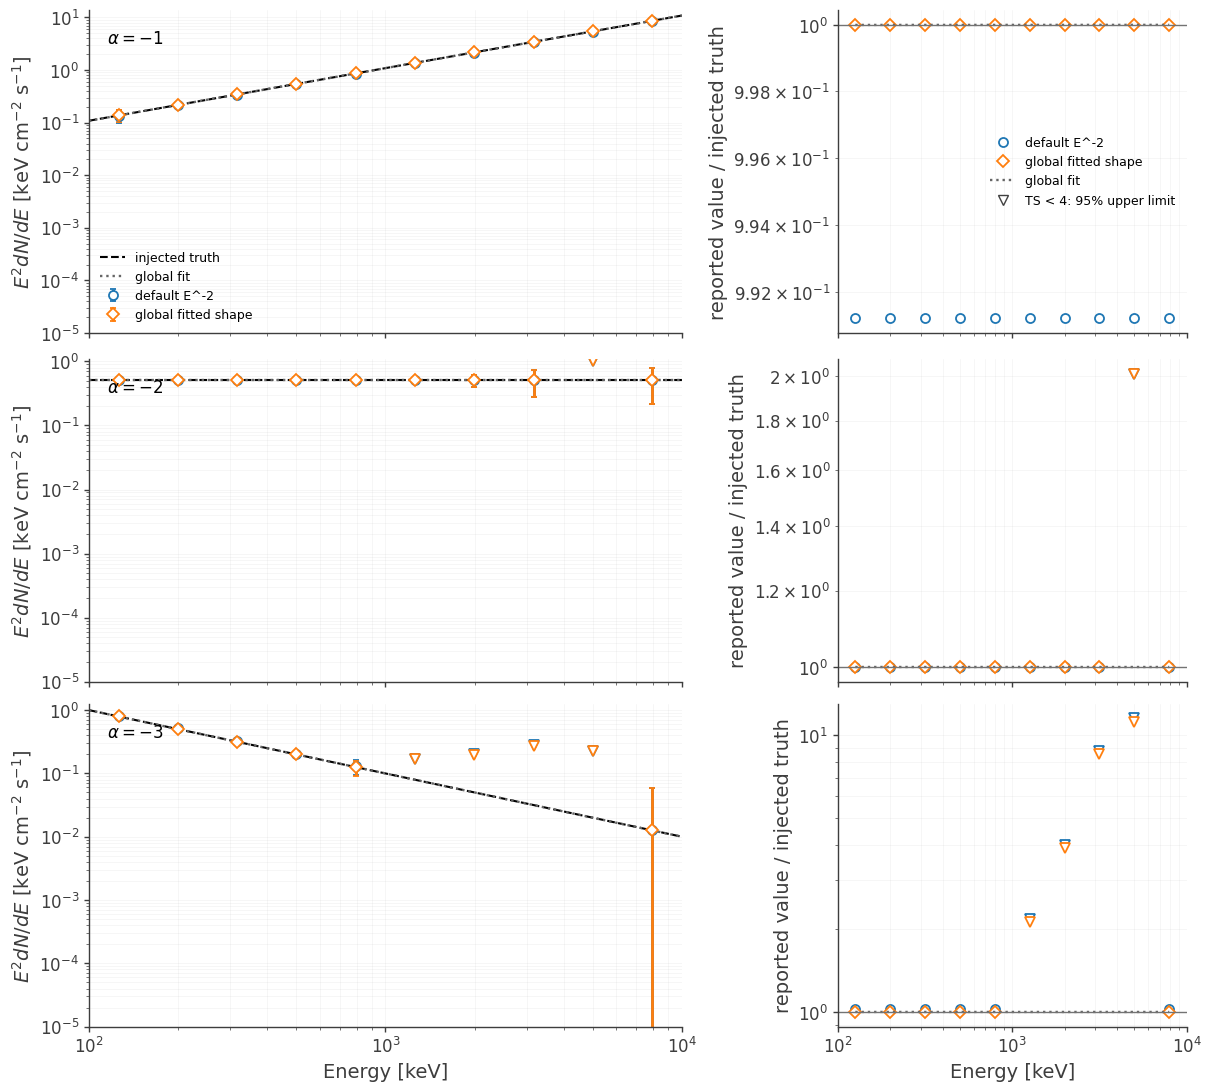

In [9]:
METHOD_STYLE = {
    "default E^-2": {"marker": "o", "color": "tab:blue"},
    "global fitted shape": {"marker": "D", "color": "tab:orange"},
}


def plot_family_comparison(family):
    selected_runs = [run for run in comparison_runs if run["family"] == family]
    fig, axes = plt.subplots(
        len(selected_runs), 2, figsize=(12, 3.6 * len(selected_runs)),
        sharex="col", gridspec_kw={"width_ratios": (1.7, 1.0)},
        layout="constrained",
    )
    plot_energy = np.geomspace(ei_edges[0], ei_edges[-1], 500)

    for row, run in enumerate(selected_runs):
        ax_sed, ax_residual = axes[row]
        truth_curve = np.asarray(run["truth_shape"](plot_energy), dtype=float)
        global_shape = run["global_fit"]["shape"]
        global_curve = np.asarray(global_shape(plot_energy), dtype=float)
        ax_sed.plot(
            plot_energy, plot_energy**2 * truth_curve, "k--", lw=1.5,
            label="injected truth",
        )
        ax_sed.plot(
            plot_energy, plot_energy**2 * global_curve, color="0.4",
            ls=":", lw=1.7, label="global fit",
        )

        case_results = sed_results[
            (sed_results["family"] == family)
            & (sed_results["case_value"] == run["case_value"])
        ]
        for method, style in METHOD_STYLE.items():
            table = case_results[case_results["method"] == method].sort_values("bin")
            x = table["energy_keV"].to_numpy()
            detected = ~table["is_ul"].to_numpy(dtype=bool)
            upper = ~detected
            y = x**2 * table["flux"].to_numpy()
            yerr = x**2 * table["flux_error"].to_numpy()
            ax_sed.errorbar(
                x[detected], y[detected], yerr=yerr[detected],
                fmt=style["marker"], ms=6.5, capsize=2,
                color=style["color"], markerfacecolor="white",
                markeredgewidth=1.3, linestyle="none", label=method,
            )
            if np.any(upper):
                ul_y = x[upper]**2 * table.loc[upper, "ul95"].to_numpy()
                ax_sed.plot(
                    x[upper], ul_y, marker="v", ms=6.5,
                    color=style["color"], markerfacecolor="white",
                    markeredgewidth=1.3, linestyle="none",
                )
            detection_ratio = (
                table.loc[detected, "flux"].to_numpy()
                / table.loc[detected, "truth"].to_numpy()
            )
            ax_residual.plot(
                x[detected], detection_ratio,
                marker=style["marker"],
                ms=6.5, color=style["color"], markerfacecolor="white",
                markeredgewidth=1.3, linestyle="none", label=method,
            )
            if np.any(upper):
                ul_ratio = (
                    table.loc[upper, "ul95"].to_numpy()
                    / table.loc[upper, "truth"].to_numpy()
                )
                ax_residual.plot(
                    x[upper], ul_ratio, marker="v", ms=6.5,
                    color=style["color"], markerfacecolor="white",
                    markeredgewidth=1.3, linestyle="none",
                )

        global_at_bins = np.asarray(global_shape(energy), dtype=float)
        truth_at_bins = np.asarray(run["truth_shape"](energy), dtype=float)
        global_ratio = global_at_bins / truth_at_bins
        ax_residual.plot(
            energy, global_ratio, color="0.4", ls=":", lw=1.7,
            label="global fit",
        )

        ax_sed.text(0.03, 0.94, run["case_label"], transform=ax_sed.transAxes, va="top")
        ax_sed.set_xscale("log")
        ax_sed.set_yscale("log")
        ax_sed.set_xlim(ei_edges[0], ei_edges[-1])
        ax_sed.set_ylim(bottom=1.0e-5)
        ax_sed.set_ylabel(r"$E^2 dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
        ax_sed.grid(alpha=0.2, which="both")
        ax_residual.axhline(1.0, color="0.45", lw=1.0)
        ax_residual.set_xscale("log")
        ax_residual.set_yscale("log")
        ax_residual.set_xlim(ei_edges[0], ei_edges[-1])
        ax_residual.set_ylabel("reported value / injected truth")
        ax_residual.grid(alpha=0.2, which="both")

        if row == 0:
            ax_residual.plot(
                [], [], marker="v", ms=6.5, color="0.25",
                markerfacecolor="white", linestyle="none",
                label="TS < 4: 95% upper limit",
            )
            ax_sed.legend(frameon=False, fontsize=9)
            ax_residual.legend(frameon=False, fontsize=9)

    axes[-1, 0].set_xlabel("Energy [keV]")
    axes[-1, 1].set_xlabel("Energy [keV]")
    plt.show()


plot_family_comparison("powerlaw")

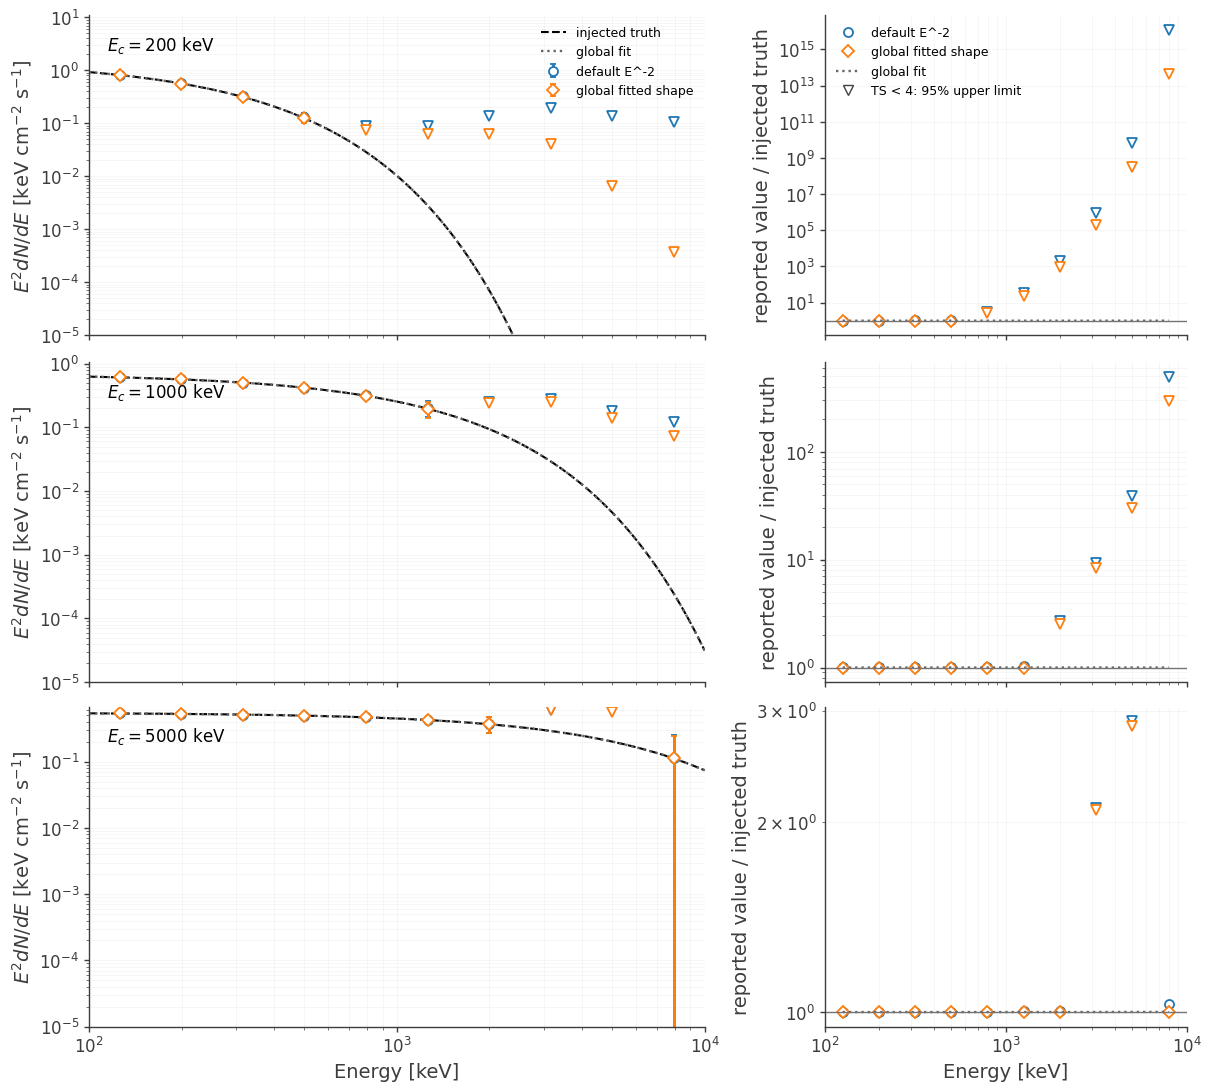

In [10]:
plot_family_comparison("cutoff_powerlaw")

## Interpretation

For the $\alpha=-2$ power-law control, the two BinnedSED constructions should be equivalent apart from optimizer tolerance because their within-bin shapes are the same. In the other cases, the globally fitted shape can reduce within-bin shape mismatch. This does not make the SED globally parametric: after the shape is copied and frozen, every $K_i$ is still fitted independently.

The global shape is estimated from the same data, so these two reconstructions are statistically correlated. The displayed Hessian bars are marginal uncertainties from each fit and do not encode the cross-method covariance. The Asimov construction also removes Poisson realization noise; repeat the injection with Poisson sampling if ensemble coverage is the scientific question.